# Problem Set 3, Task 1- LSTM: Predict IBM Stock Price
# Juan Pablo Brasdefer
## November 2024
## Applied Neural Networks - prof. Ziogas


Your goal is to build a Long Short-Term Memory (LSTM) network to predict a market price (in this case, IBM). Follow the steps below:
1. Inspect the Keras time-series forecasting notebook example (here).
2. Download the IBM stock price data from Canvas.
3. Adapt the Keras template to predict the IBM stock. Your test set should include all obser- vations from 2017-01-01 onwards.
4. Assess the performance of your model.
5. (Optional) Discuss any challenges you faced when building the model.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import keras
from google.colab import files
import io

In [2]:
# import IBM stock data
uploaded = files.upload()
df_raw = pd.read_csv(io.BytesIO(uploaded['IBM.csv'])) # in a dataframe format, replacing dictionary



Saving IBM.csv to IBM.csv


In [3]:
print(df_raw.shape)
# great

(3020, 7)


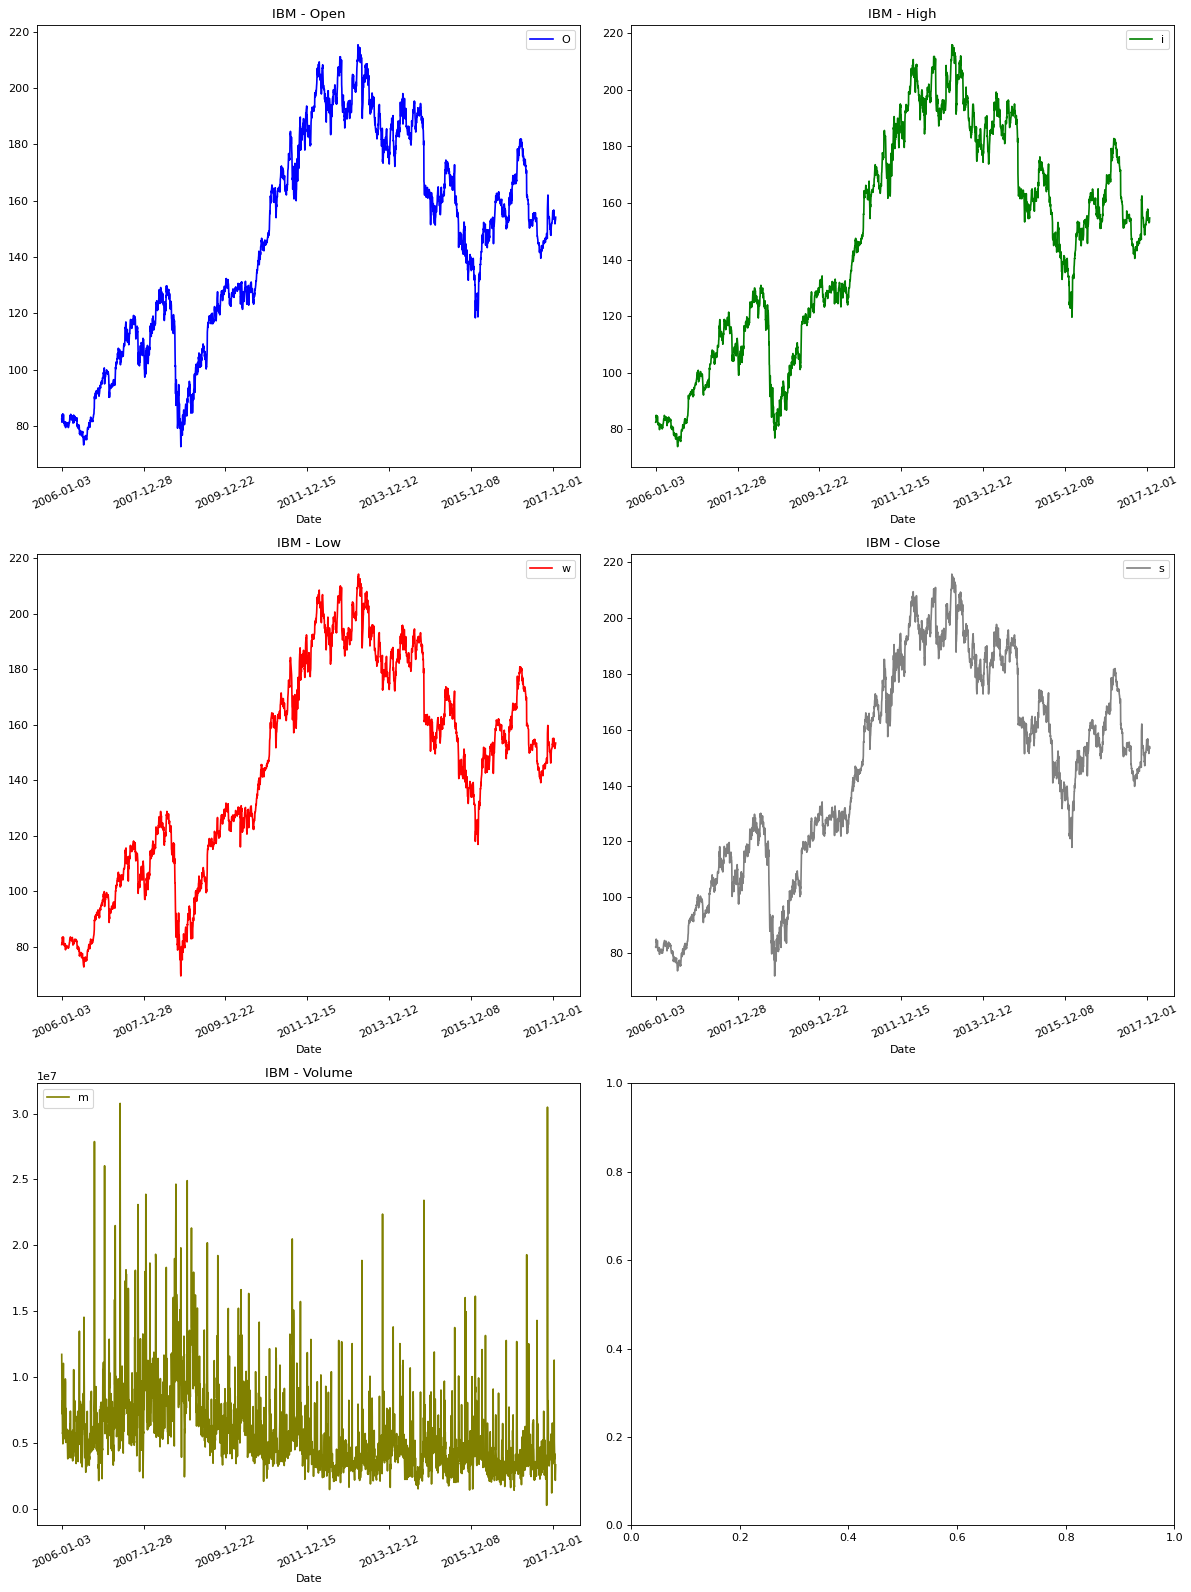

In [4]:
# @title Exploratory Graphs

feature_keys = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]

colors = [
    "blue",
    "green",
    "red",
    "gray",
    "olive",
]

date_time_key = "Date"


def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(
        nrows=3, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i in range(len(feature_keys)):
        key = feature_keys[i]
        c = colors[i % (len(colors))]
        t_data = data[key]
        t_data.index = time_data
        t_data.head()
        ax = t_data.plot(
            ax=axes[i // 2, i % 2],
            color=c,
            title="IBM - {}".format(key),
            rot=25,
        )
        ax.legend([key[i]])
    plt.tight_layout()


show_raw_visualization(df_raw)


## Data Preprocessing



In [5]:
df = df_raw.copy() # quick copy so we don't have to re-upload over and over

In [6]:
df.set_index('Date', inplace=True) # set our date column as index instead of feature

# split the data, as is specified in assignment instructions
# anything after jan 1st 2017 is not for training
train_split = len(df[:'2016-12-31'])


In [7]:

def normalize(data, train_split):
    data_mean = data[:train_split].mean(axis=0)
    data_std = data[:train_split].std(axis=0)
    return (data - data_mean) / data_std


In [8]:
features = df.drop('Name', axis=1) # we don't need to know "IBM" for every single observation
features.head() # quick look

,Open,High,Low,Close,Volume
Date,,,,,
2006-01-03,82.45,82.55,80.81,82.06,11715200
2006-01-04,82.20,82.50,81.33,81.95,9840600
2006-01-05,81.40,82.90,81.00,82.50,7213500
2006-01-06,83.95,85.03,83.41,84.95,8197400
2006-01-09,84.10,84.25,83.38,83.73,6858200


In [9]:
#selected_features = [feature_keys[i] for i in [0,1,2,3,4]]
#features = df[selected_features]
#features.index = df[date_time_key]
#features.head()

features = normalize(features.values, train_split) # re-scale features
features = pd.DataFrame(features)
features.head()

,0,1,2,3,4
0,-1.594814,-1.619959,-1.613259,-1.608579,1.809594
1,-1.601249,-1.621243,-1.599845,-1.611411,1.225142
2,-1.621842,-1.610967,-1.608358,-1.597248,0.406080
3,-1.556203,-1.556248,-1.546188,-1.534157,0.712835
4,-1.552342,-1.576286,-1.546962,-1.565574,0.295307


In [10]:
train_data = features.loc[0 : train_split - 1] # set training data partition
val_data = features.loc[train_split:] # set remaining for validation data

print("train_data shape:", train_data.shape)
print("val_data shape:", val_data.shape)
print("total length", len(train_data)+len(val_data))

train_data shape: (2769, 5)
val_data shape: (251, 5)
total length 3020


# Creating Training and Validation datasets



In [11]:
# set our domain-specific parameters
step = 1     # Use every day's data point, no downsampling
past = 30    # Look at the past 30 days
future = 5   # Predict 5 days ahead
batch_size = 16 # play with batch sizes
epochs = 20
learning_rate = 0.001

# set starts and ends based on domain-specific parameters
#start = past + future # 60 days of history + 5 days future to ensure we have enough data for 1st iteration
#end = start + train_split # cutoff for training data
#label_start = train_split + past + future # first predicted observation for val set
#x_end = len(val_data) - past - future # to ensure we don't eat into val set

In [12]:
# Calculate start index for target labels
y_train_start = past + future
y_val_start = y_train_start + len(train_data)

In [13]:
# create train and test
x_train = train_data.values
y_train = features.iloc[y_train_start:y_val_start][[1]].values

# create train and test
x_val = val_data.values
y_val = features.iloc[y_val_start:][[1]].values

In [14]:
# NOT THE MOST ELEGANT SOLUTION IN THE WORLD
# MANUAL SLICING
# TRY TO CHANGE THIS to better method if you have time
# Adjust `x_val` to match `y_val` size
x_val = x_val[:len(y_val)]  # Ensures `x_val` and `y_val` have compatible sizes

In [15]:
#sequence_length = int(past / step) # this was giving me tons of trouble
#sequence_length=len(x_val) # this seems to be the solution. thanks ANNs github discussion forum!
sequence_length = past

In [16]:
dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

for batch in dataset_train.take(1):
    inputs, targets = batch

print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)

Input shape: (16, 30, 5)
Target shape: (16, 1)


In [17]:
dataset_train
#should ideally have shapes
 #(batch_size, sequence_length, num_features) and
 #(batch_size, target_size) for targets

 #aka
 #(16, 30, 5)
 #(16, 1)

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 5), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.float64, name=None))>

In [18]:
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

x_train shape: (2769, 5)
y_train shape: (2769, 1)
x_val shape: (216, 5)
y_val shape: (216, 1)


In [19]:
dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    batch_size=batch_size,
)
print("Length of x_val:", len(x_val))
print("Length of y_val:", len(y_val))

Length of x_val: 216
Length of y_val: 216


In [20]:
dataset_val

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 5), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.float64, name=None))>

## Training

In [21]:
inputs = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
lstm_out = keras.layers.LSTM(32)(inputs)
outputs = keras.layers.Dense(1)(lstm_out)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse", metrics=['mae'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 30, 5)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 32)                  │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)

We'll use the `ModelCheckpoint` callback to regularly save checkpoints, and
the `EarlyStopping` callback to interrupt training when the validation loss
is not longer improving.

In [23]:
path_checkpoint = "model_checkpoint.weights.h5"
es_callback = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=0, patience=5)

modelckpt_callback = keras.callbacks.ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history = model.fit(
    dataset_train,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)

Epoch 1/20
169/172 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0187 - mae: 0.1111
Epoch 1: val_loss did not improve from inf
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0187 - mae: 0.1109 - val_loss: nan - val_mae: nan
Epoch 2/20
171/172 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0176 - mae: 0.1074
Epoch 2: val_loss did not improve from inf
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0176 - mae: 0.1073 - val_loss: nan - val_mae: nan
Epoch 3/20
169/172 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0167 - mae: 0.1047
Epoch 3: val_loss did not improve from inf
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0167 - mae: 0.1047 - val_loss: nan - val_mae: nan
Epoch 4/20
168/172 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0162 - mae: 0.1027
Epoch 4: val_loss did not improve from inf
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.0162 - mae: 0.1026 - val_loss: nan - val_mae: nan
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0157 - mae: 0.1011
Epoch 5: v

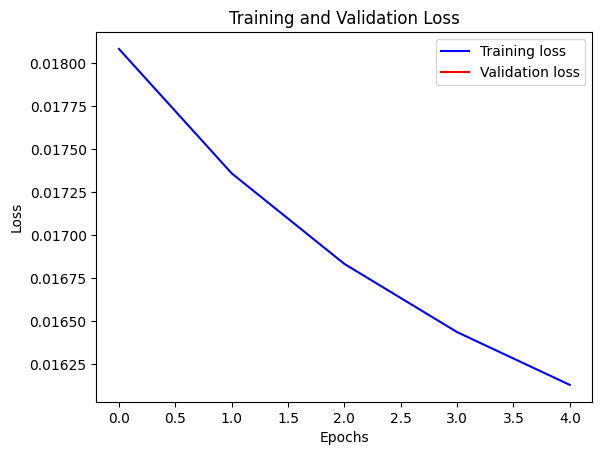

In [24]:

def visualize_loss(history, title):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


visualize_loss(history, "Training and Validation Loss")

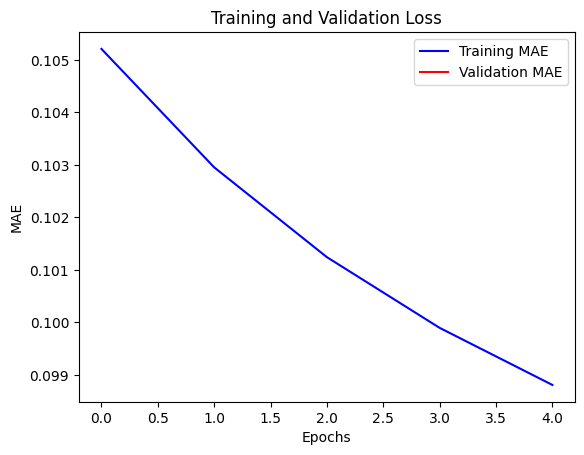

In [25]:
def visualize_loss(history, title):
    loss = history.history["mae"]
    val_loss = history.history["val_mae"]
    epochs = range(len(loss))
    plt.figure()
    plt.plot(epochs, loss, "b", label="Training MAE")
    plt.plot(epochs, val_loss, "r", label="Validation MAE")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()


visualize_loss(history, "Training and Validation Loss")

No validation loss???? I thought I fixed the empty dataset_val issue...

## Prediction

The trained model above is now able to make predictions for 5 sets of values from
validation set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step


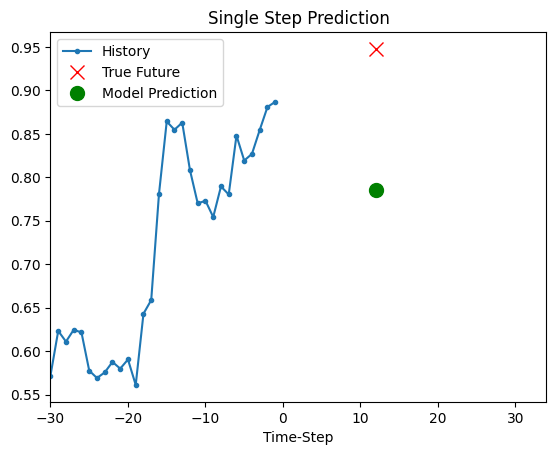

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


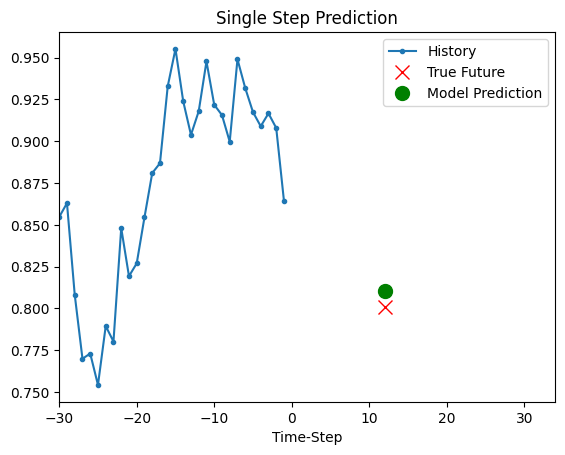

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


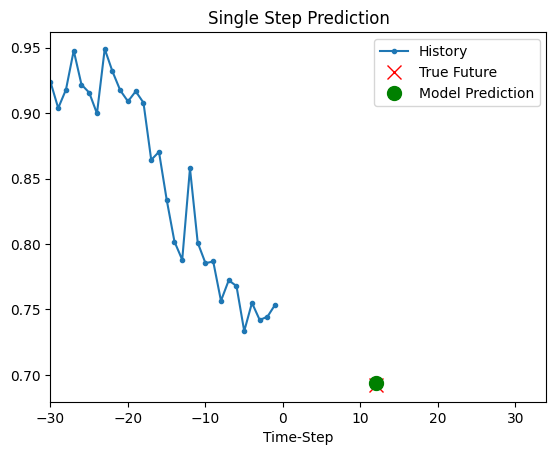

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


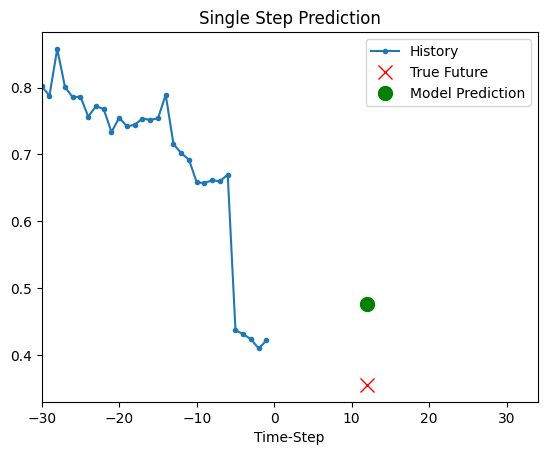

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


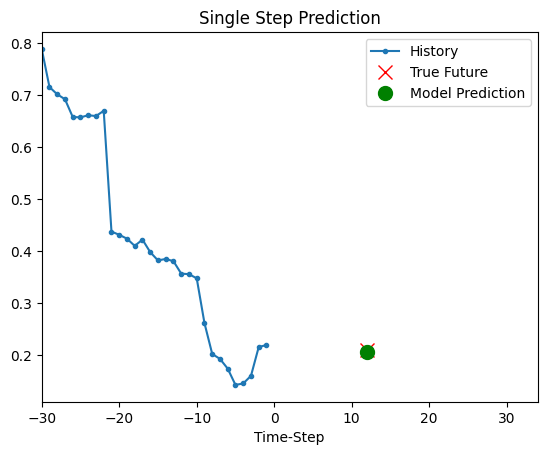

In [26]:

def show_plot(plot_data, delta, title):
    labels = ["History", "True Future", "Model Prediction"]
    marker = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))
    if delta:
        future = delta
    else:
        future = 0

    plt.title(title)
    for i, val in enumerate(plot_data):
        if i:
            plt.plot(future, plot_data[i], marker[i], markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    plt.legend()
    plt.xlim([time_steps[0], (future + 5) * 2])
    plt.xlabel("Time-Step")
    plt.show()
    return


for x, y in dataset_val.take(5):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), model.predict(x)[0]],
        12,
        "Single Step Prediction",
    )

### Challenges faced when building the model

Just one very large challenge that I still don't think I've overcome.
For a long time, I was stuck on creating the validation set. Everything ran fine, but my validation set had no loss and no MAE, which prompted me to check its contents. The validation dataset object created with keras.preprocessing.timeseries_dataset_from_array was strangely missing rows.

<_BatchDataset element_spec=(TensorSpec(shape=(None, None, 5), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1), dtype=tf.float64, name=None))>

After some digging, it seemed that the 'None' was actually fine, and just placeholders, but my training showed no validation loss? I believe it is not training properly. However, the  Prediction graphs look great (relative to the training val). I'm not entirely sure what is happening, and would need to investigate further.

I also consulted with Daniel about how he overcame the problem (using len(x_val) for sequence_length), but it did not fix this for me...

## Resources Used

Prabhanshu Attri. et. al. 2023. "Timeseries forecasting for weather prediction". https://keras.io/examples/generative/text_generation_with_miniature_gpt/



OpenAI. 2024. ChatGPT (GPT-4o) [Large language model]. https://chat.openai.com/chat